<div align='right'>
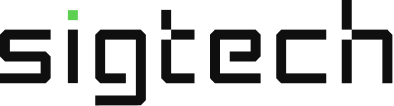
</div>

# Swaps Demo

- Environment
- Objects
- Building Blocks
- Example Strategies

___

## Environment

In [1]:
import datetime as dtm
import pandas as pd
import numpy as np

In [2]:
import sigtech.framework as sig

env = sig.init()

SigTech environment successfully initialized


___

## Objects

There are three fundamental objects in the platform:
- **Tradable instruments**: instruments, tradable on the financial markets,
- (Tradable) **Strategies**: a set of rules and logic to buy or sell tradable instruments over time,
- **Non-tradable data**: objects that are used for signalling purposes or research like macro-economic data.
<br>

<div align='center'>
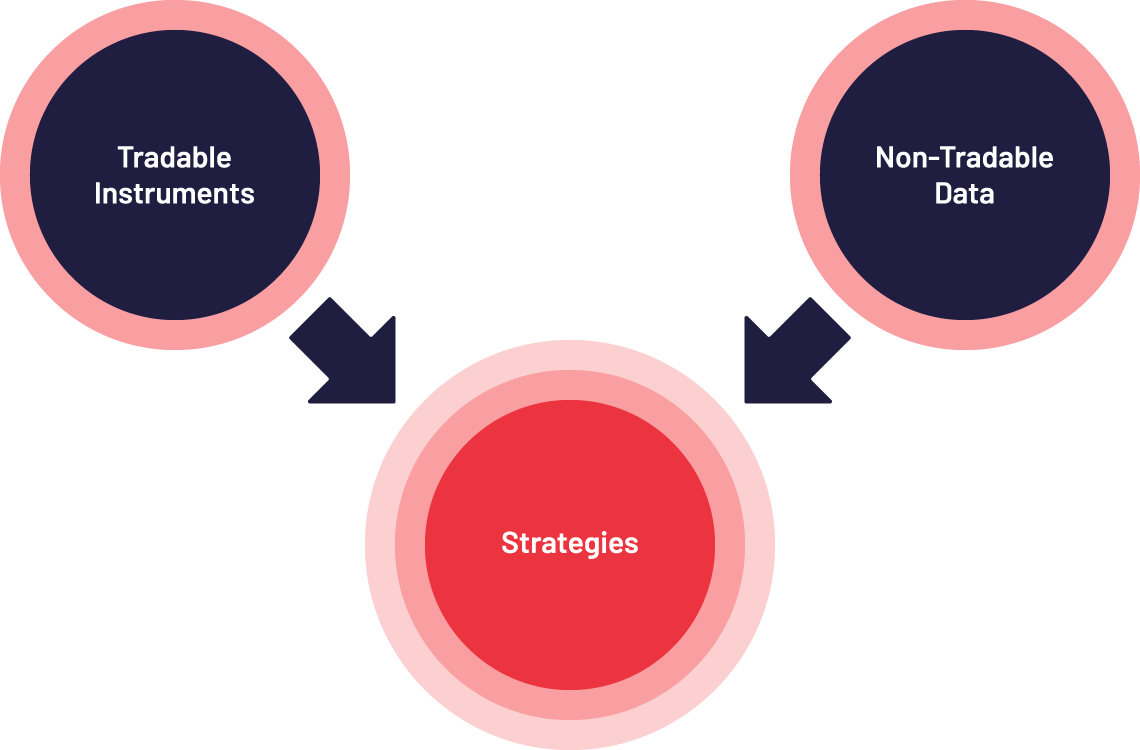
</div>


In [3]:
sig.InterestRateSwap?

Init signature: sig.InterestRateSwap(*args, cache: bool = True, **kwargs)
Docstring:     
Implements a receiver (receives fixed, pays floating) interest rate swap where its P&L excluding cashflows is
calculated from a given time series. Strike will be recorded as an entry point on the time series + transaction
cost assumptions (unless specified explicitly). The name will be different depending on whether the swap will start
on the next IMM contract delivery date.

The history of the swap is computed to the earliest of the pricing day and swap maturity unless value_post_start is
set to False in which case the swap will only have time series from entry date until start date.

If floating leg requires a spread on top of the index, it can be added as a ``spread`` parameters (in absolute
terms, e.g. if a floating leg pays LIBOR+20bp, the 20bp should be input as ``spread=0.002``).

Example object creation:

::

    ir_swap = InterestRateSwap(
        currency='USD',
        trade_date=dtm.da

In [4]:
ir_swap = sig.InterestRateSwap(
    currency="USD",
    trade_date=dtm.date(2017, 4, 14),
    tenor="10Y",
)

In [5]:
ir_swap.history_fields

['LastPrice', 'Rate', 'PV01']

<AxesSubplot:>

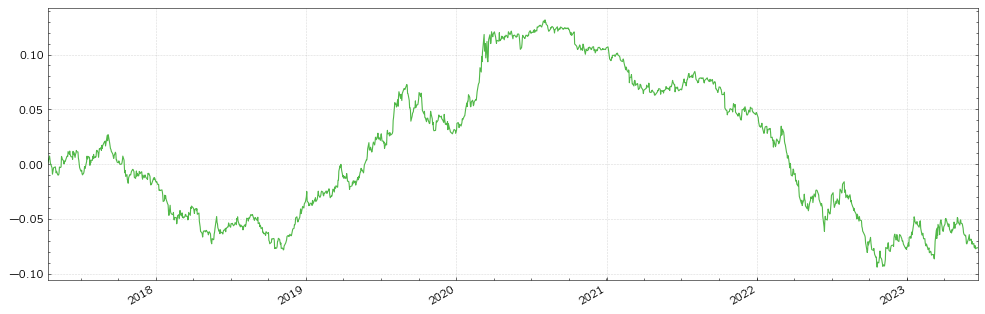

In [6]:
ir_swap.history().plot()

In [7]:
ir_swap.history("PV01").tail()

2023-06-14    0.000366
2023-06-15    0.000366
2023-06-16    0.000366
2023-06-20    0.000366
2023-06-21    0.000366
Name: (PV01, EOD, USD LIBOR S3M 0.0220949 2017-04-14 2017-04-19X10Y IRS), dtype: float64

In [8]:
ir_swap.history("Rate").tail()

2023-06-14    4.294844
2023-06-15    4.239103
2023-06-16    4.319700
2023-06-20    4.290061
2023-06-21    4.291603
Name: (Rate, EOD, USD LIBOR S3M 0.0220949 2017-04-14 2017-04-19X10Y IRS), dtype: float64

In [9]:
ir_swap.swap_details(dtm.date.today())

{'float_leg_pv': -0.1571119074217379,
 'fixed_leg_pv': 0.08088780010213298,
 'pv01': 0.00036609139316580414,
 'float_leg_pv_with_notional': -1.0186724571382029,
 'fixed_leg_pv_with_notional': 0.9424483498185978,
 'npv': -0.07622410731960491,
 'fixed_rate': 0.022094974537,
 'fair_rate': 0.04291603418018115,
 'params': {'float_day_count': 'Actual/360',
  'fixed_day_count': '30/360 (Bond Basis)',
  'start_date': datetime.date(2017, 4, 19),
  'maturity': datetime.date(2027, 4, 19)},
 'fixed_flows': [(datetime.date(2023, 10, 19), 0.011047487268500022),
  (datetime.date(2024, 4, 19), 0.011047487268500022),
  (datetime.date(2024, 10, 21), 0.011170237127038796),
  (datetime.date(2025, 4, 22), 0.01110886219776952),
  (datetime.date(2025, 10, 20), 0.010924737409961027),
  (datetime.date(2026, 4, 20), 0.011047487268500022),
  (datetime.date(2026, 10, 19), 0.010986112339230525),
  (datetime.date(2027, 4, 19), 0.011047487268500022)],
 'floating_flows': [(datetime.date(2023, 7, 19), 0.01330874999999

In [10]:
ir_swap.carry_roll_down(
    d=dtm.date.today(),
    dates=[
        dtm.date(2023, 6, 1),
        dtm.date(2023, 12, 1),
        dtm.date(2024, 6, 1),
        dtm.date(2024, 12, 1),
    ],
)

,carry,roll_down,carry/pv01,roll_down/pv01
2023-06-01,NaN,0.001339,NaN,3.657607
2023-12-01,-0.016380,0.005567,-44.742342,15.207004
2024-06-01,-0.033416,0.010769,-91.277436,29.415993
2024-12-01,-0.050636,0.016704,-138.315615,45.627923


In [11]:
ir_swap._discounting_curve()

USD.D CURVE <class 'sigtech.framework.internal.infra.curves.dynamic_curve.OISCurve'>[140604109827184]

In [12]:
ir_swap._forecasting_curve()

USD.F3M CURVE <class 'sigtech.framework.internal.infra.curves.dynamic_curve.ProjectionCurveDF'>[140604109857504]

___

## Additional Swaps

In [13]:
ois_swap = sig.OISSwap(
    currency="USD",
    tenor="10Y",
    trade_date=dtm.date(2019, 7, 1),
)

In [14]:
ois_swap.history().tail()

2023-06-14   -0.123336
2023-06-15   -0.120000
2023-06-16   -0.123142
2023-06-20   -0.121813
2023-06-21   -0.121880
Name: (LastPrice, EOD, USD A FEDL01 0.01745 2019-07-01 2019-07-03X10Y OIS SWAP), dtype: float64

In [15]:
xccy_swap = sig.CrossCurrencySwap(
    currency="USD",
    pay_currency="EUR",
    tenor="10Y",
    trade_date=dtm.date(2021, 7, 1),
)

In [16]:
xccy_swap.history().tail()

2023-06-13    0.091028
2023-06-14    0.088643
2023-06-15    0.079772
2023-06-16    0.080402
2023-06-20    0.083414
Name: (LastPrice, EOD, FLOAT USD FLOAT 0.842574 EUR SPRD -0.001146 2021-07-06X10Y TRADED 2021-07-01 XCCY SWAP), dtype: float64

In [17]:
xccy_swap.spread

-0.0011456185515991088

In [18]:
swap_quote = sig.obj.get("USD.10Y SWAP QUOTE")

In [19]:
swap_quote.intraday_history().tail()

trading_datetime
2023-06-20 20:00:00+00:00    3.732
2023-06-20 21:00:00+00:00    3.728
2023-06-20 22:00:00+00:00    3.732
2023-06-20 23:00:00+00:00    3.721
2023-06-21 00:00:00+00:00    3.736
Name: (LastPrice, USD.10Y SWAP QUOTE), dtype: float64

___

## Building Blocks

Within the SigTech platform, the user has the ability to use **Building Blocks**, a set of pre-built methods designed to speed up the process of creating basic strategies.

`RollingSwapStrategy` is the building block that rolls forward starting IMM swaps. Swaps are receivers (receiving fixed, paying floating).
* Currency
* Tenor 
* Forward Start Months


In [20]:
sig.RollingSwapStrategy?

Init signature: sig.RollingSwapStrategy(*args, cache: bool = True, **kwargs)
Docstring:     
Strategy handling the rolling of forward starting IMM swaps. Swaps are receivers (receiving fixed, paying floating).

Keyword arguments:

    * tenor: Swap tenor.
    * roll_offset: Roll days offset to the IMM swap reset dates.
    * forward_start_months: Forward swap start date (in months, multiple of 3).
    * rolling_frequency_months: Rolling frequency (in months, multiple of 3, if not specified it coincides with         ``forward_start_months)``.
    * swap_currency: Swap's underlying currency, if None strategy currency is driving the underlying swaps traded.
    * pv01_target: Trade PV01 if ``pv01_target_type`` is ``Fixed``, else PV01 per unit of notional.
    * pv01_target_type: ``Fixed`` or ``Relative``, default is ``Fixed``.
    * notional_target: Fixed notional amount for every traded swap. If ``None`` - notional scales with strategy         valuation.
    * custom_roll_table: Optional

In [21]:
rs_10y = sig.RollingSwapStrategy(
    tenor="10Y",
    currency="USD",
    rolling_frequency_months=6,
    forward_start_months=6,
    start_date=dtm.date(2010, 1, 4),
    ticker="ROLLING 10Y SWAP",
)

<AxesSubplot:>

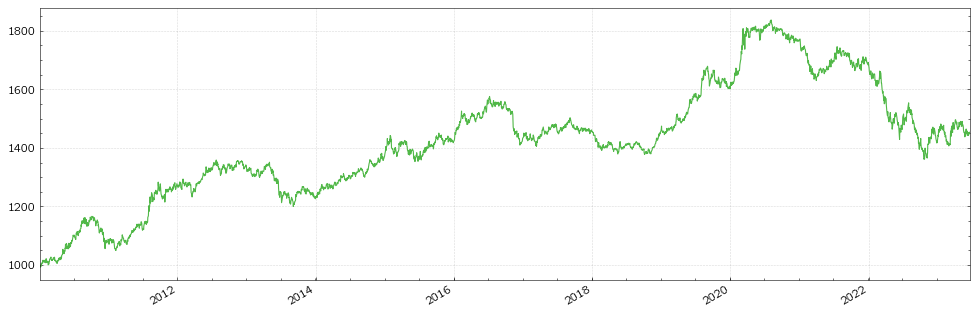

In [22]:
rs_10y.history().plot()

In [23]:
rs_10y.plot.timeline()

In [24]:
rs_pv = sig.RollingSwapStrategy(
    tenor="10Y",
    currency="USD",
    rolling_frequency_months=6,
    forward_start_months=6,
    start_date=dtm.date(2010, 1, 4),
    pv01_target=100,
    pv01_target_type="Fixed",
)

<AxesSubplot:>

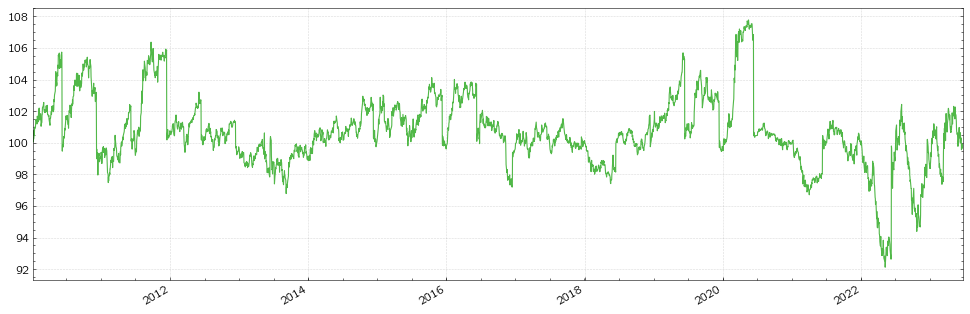

In [25]:
rs_pv.swap_pv01_series().plot()

In [26]:
rs_pv.plot.portfolio_table("TOP_ORDER_PTS", start_dt=dtm.date(2022, 1, 1))

___

## Example Strategy: CPI Signal Strategy

In [27]:
cpi = sig.obj.get("ECO CPI_ALL_ITEMS OECD US MACROECONOMICFIX")

2023-06-21 14:03:36,138 [1163] [sigtech.framework.internal.utils.deprecation] WARNING: Call to deprecated function 'history_df' from /opt/conda/envs/sig-env/lib/python3.9/site-packages/sigtech/framework/instruments/fixes.py:1068. Please use 'data_df'. 'history_df' will be removed in framework v9.


<AxesSubplot:xlabel='date'>

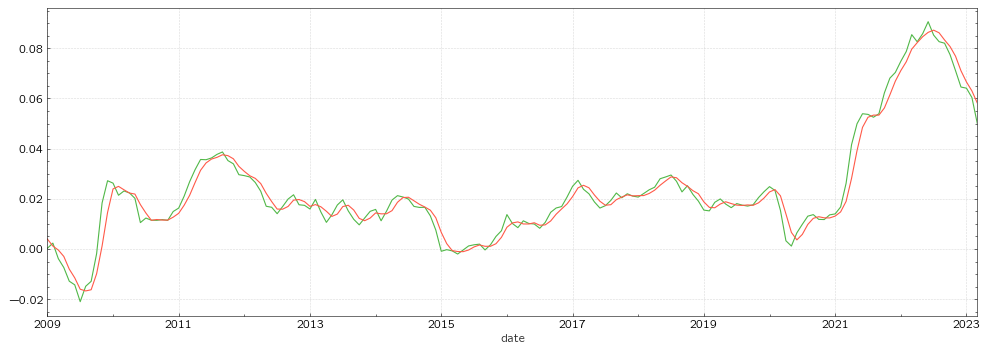

In [28]:
cpi_df = cpi.history_df()["value"].pct_change(12)
cpi_df["2009-01-01":].plot()

cpi_df.rolling(3).mean()["2009-01-01":].plot()

In [29]:
rs_2y = sig.RollingSwapStrategy(
    tenor="2Y",
    currency="USD",
    rolling_frequency_months=6,
    forward_start_months=6,
    start_date=dtm.date(2010, 1, 4),
    ticker="ROLLING 2Y SWAP",
)

In [30]:
basket = sig.BasketStrategy(
    currency="USD",
    start_date=dtm.date(2010, 1, 4),
    constituent_names=[rs_2y.name, rs_10y.name],
    weights=[0.5, -0.5],
    rebalance_frequency="3M",
    ticker="LONG 2Y SHORT 10Y SWAP",
)

<AxesSubplot:>

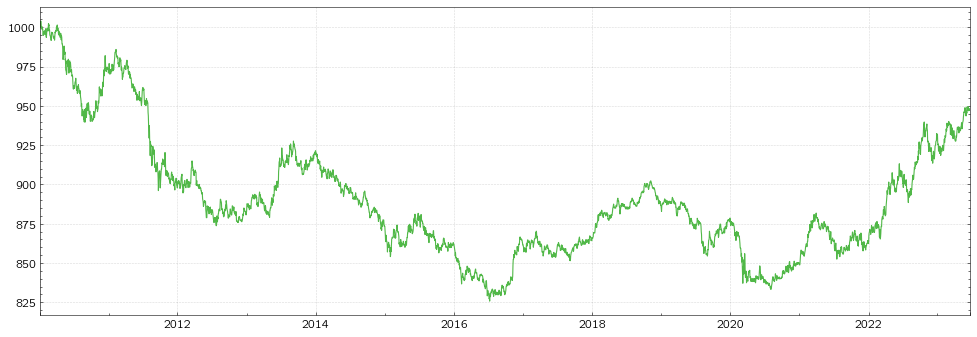

In [31]:
basket.history().plot()

In [32]:
basket.plot.tree()

,Strategy
,Position
,Cash
,Instrument Order
,Grouped Order
,Strategy Order
,FX Spot Order


In [33]:
signal_df = np.sign(cpi_df - cpi_df.rolling(3).mean()).dropna()
signal_df.name = basket.name
signal_df = signal_df.to_frame()
signal_df

,LONG 2Y SHORT 10Y SWAP STRATEGY
date,
1991-03-01,-1.0
1991-04-01,-1.0
1991-05-01,1.0
1991-06-01,-1.0
1991-07-01,-1.0
...,...
2022-11-01,-1.0
2022-12-01,-1.0
2023-01-01,-1.0


In [34]:
cpi_strategy = sig.SignalStrategy(
    currency="USD",
    start_date=dtm.date(2012, 1, 4),
    signal_name=sig.signal_library.from_ts(signal_df).name,
    use_signal_for_rebalance_dates=True,
    ticker="CPI SIGNAL",
)

<AxesSubplot:>

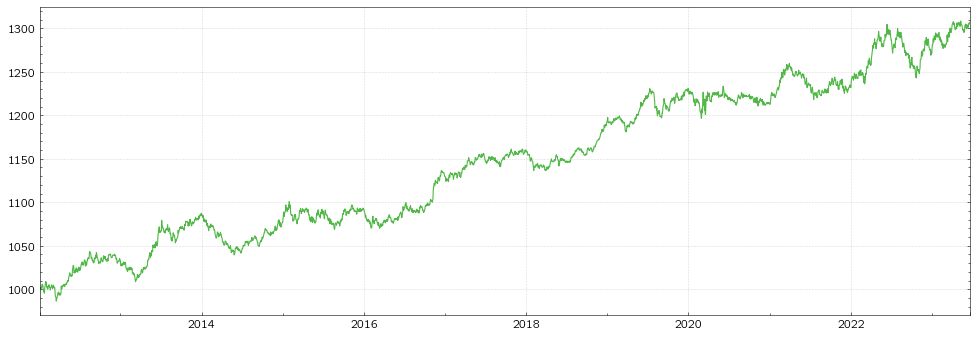

In [35]:
cpi_strategy.history().plot()

In [36]:
cpi_strategy.plot.timeline()

___

## Example Strategy: 

In [37]:
ccys = ["USD", "EUR", "GBP", "JPY", "AUD", "CAD", "NZD", "NOK"]

In [38]:
def create_rolling_swaps(ccy):
    return sig.RollingSwapStrategy(
        tenor="5Y",
        currency=ccy,
        rolling_frequency_months=3,
        forward_start_months=3,
        start_date=dtm.date(2010, 1, 4),
        ticker=f"ROLLING {ccy} 5Y SWAP",
    )

In [39]:
swaps_universe = [create_rolling_swaps(x) for x in ccys]

In [40]:
swaps_pv01 = pd.DataFrame({s.name: s.swap_pv01_series().pct_change(21) for s in swaps_universe}).dropna()
swaps_pv01.index = swaps_pv01.index.date

In [41]:
swaps_pv01

,ROLLING USD 5Y SWAP STRATEGY,ROLLING EUR 5Y SWAP STRATEGY,ROLLING GBP 5Y SWAP STRATEGY,ROLLING JPY 5Y SWAP STRATEGY,ROLLING AUD 5Y SWAP STRATEGY,ROLLING CAD 5Y SWAP STRATEGY,ROLLING NZD 5Y SWAP STRATEGY,ROLLING NOK 5Y SWAP STRATEGY
2010-02-05,0.012326,0.010793,0.013036,0.000226,0.015165,0.010218,0.012726,0.011026
2010-02-08,0.013086,0.009900,0.011337,0.000459,0.015602,0.008556,0.014805,0.010747
2010-02-09,0.009850,0.007701,0.008651,0.000723,0.013163,0.006841,0.012907,0.009351
2010-02-10,0.007213,0.007509,0.009024,0.000287,0.013369,0.003953,0.013564,0.008119
2010-02-12,0.007837,0.008678,0.009827,0.000546,0.009134,0.005383,0.012075,0.007774
...,...,...,...,...,...,...,...,...
2023-06-13,0.005422,-0.004295,-0.021791,-0.000011,0.000363,-0.021933,0.006984,-0.008737
2023-06-14,0.005139,0.009362,-0.054616,0.011058,0.002021,-0.019233,0.008768,-0.030699
2023-06-15,0.008192,0.007761,-0.055892,0.010721,0.001236,-0.013783,0.011715,-0.030626
2023-06-16,0.007705,0.010369,-0.056550,0.010637,0.000684,-0.013399,0.012996,-0.030469


In [42]:
pv01_strategy = sig.RatesSignalStrategy(
    currency="USD",
    start_date=dtm.date(2012, 1, 4),
    signal_name=sig.signal_library.from_ts(swaps_pv01).name,
    rebalance_frequency="3M",
    allocation_function=sig.signal_library.allocation.long_short_dollar_neutral,
    allocation_kwargs={"proportion": 0.25},
)

<AxesSubplot:>

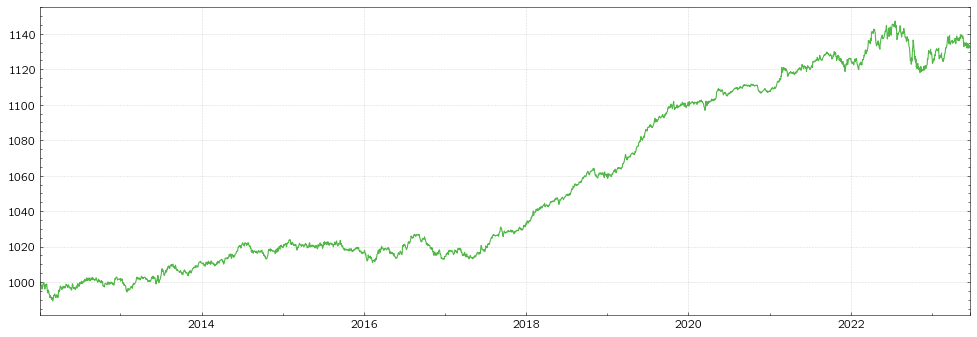

In [43]:
pv01_strategy.history().plot()

In [44]:
pv01_strategy.plot.timeline()

In [45]:
pv01_strategy.plot.portfolio_table()

In [46]:
pv01_strategy.pv01_exposure()

,USD,NZD,AUD,JPY,EUR,CAD,NOK,GBP
,5Y,5Y,5Y,5Y,5Y,5Y,5Y,5Y
2012-01-04 23:59:00+00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
2012-01-05 23:59:00+00:00,-0.123174,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
2012-01-06 23:59:00+00:00,-0.123206,0.144708,0.107937,-9.569960,0.000000,0.0,0.000000,0.000000
2012-01-09 23:59:00+00:00,-0.123235,0.144651,0.107986,-9.569960,0.000000,0.0,0.000000,0.000000
2012-01-10 23:59:00+00:00,-0.123234,0.144560,0.107960,-9.568575,0.000000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...
2023-06-15 23:59:00+00:00,0.000000,0.000000,0.184593,0.000000,-0.117435,0.0,-1.250294,0.094413
2023-06-16 23:59:00+00:00,0.000000,0.000000,0.184328,0.000000,-0.117478,0.0,-1.250208,0.094271
2023-06-19 23:59:00+00:00,0.000000,0.000000,0.184178,0.000000,-0.117340,0.0,-1.249225,0.094041


In [47]:
pv01_strategy_fx_hedged = sig.FXForwardHedgingStrategy(
    currency="USD",
    start_date=dtm.date(2012, 1, 4),
    strategy_name=pv01_strategy.name,
    hedging_tenor="3M_IMM",
    use_holdings_for_hedge_ccy=True,
    exposure_rebalance_threshold=0,
    hedge_rebalance_threshold=0,
)

<AxesSubplot:>

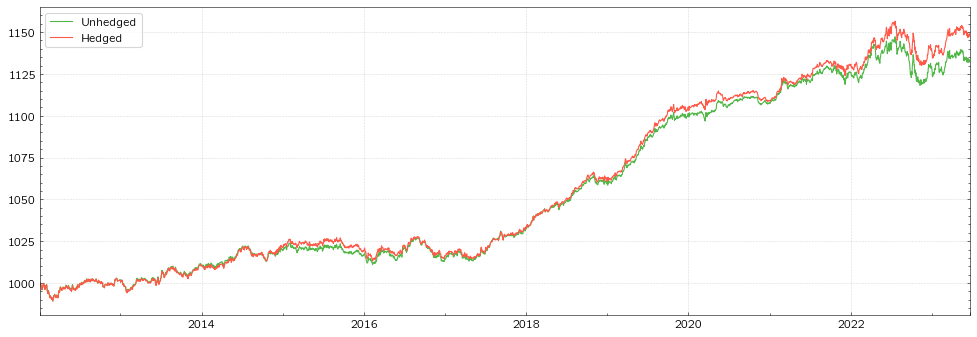

In [48]:
pv01_strategy.history().plot(label="Unhedged", legend=True)
pv01_strategy_fx_hedged.history().plot(label="Hedged", legend=True)

In [49]:
pv01_strategy_fx_hedged.plot.portfolio_table()

___

## Combining Strategies

In [50]:
simple_basket = sig.BasketStrategy(
    currency="USD",
    start_date=dtm.date(2012, 1, 4),
    constituent_names=[cpi_strategy.name, pv01_strategy.name],
    weights=[0.5, 0.5],
    rebalance_frequency="3M",
)

<AxesSubplot:>

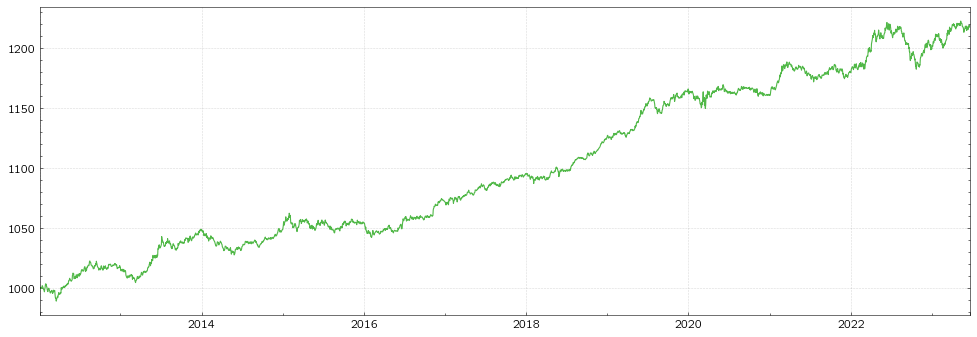

In [51]:
simple_basket.history().plot()

In [52]:
combined_df = pd.DataFrame(
    {
        cpi_strategy.name: cpi_strategy.history(),
        pv01_strategy.name: pv01_strategy.history(),
    }
)

In [53]:
combined_df

,CPI SIGNAL STRATEGY,USD 14C8124F RSS STRATEGY
2012-01-04,1000.000000,1000.000000
2012-01-05,1000.001944,1000.001944
2012-01-06,1001.632760,999.441694
2012-01-09,999.916846,999.250161
2012-01-10,1000.388862,998.320449
...,...,...
2023-06-15,1305.480224,1134.049660
2023-06-16,1304.540669,1132.404868
2023-06-19,1305.089557,1132.029791
2023-06-20,1306.922561,1133.298625


In [54]:
sig.Optimizer?

Init signature:
sig.Optimizer(
    factor_exposures: Optional[sigtech.framework.analytics.optimization.factor_exposure.FactorExposures] = None,
    optimization_problem: Optional[sigtech.framework.analytics.optimization.optimization_problem.OptimizationProblem] = None,
    factor_exposure_kwargs: Optional[dict] = None,
    cvx_kwargs: Optional[dict] = None,
    scipy_kwargs: Optional[dict] = None,
)
Docstring:     
A class implementing an optimisation task.

To run an optimisation problem, a ``OptimizationProblem`` object needs to be provided.

If fit requires Factors then the ``FactorExposures`` containing the data must also be passed and the weights are     found with ``Optimizer.calculate_optimized_weights``.
Otherwise, if the optimization does not require knowledge of factors, ``FactorExposures=None`` is valid but     ``calculate_optimized_weights_with_fit`` must be used.

.. seealso:: `sigtech.framework.analytics.optimization.optimization_problem.OptimizationProblem`

An example o

In [55]:
po = (
    sig.PortfolioOptimizer()
    .prefer_inverse_vol_weighting()
    .require_long_only()
    .require_weight_limit(min_value=1, max_value=2)
)

optimized_strategy_inverse_vol = sig.SignalStrategy(
    currency="USD",
    start_date=dtm.date(2013, 1, 1),
    rebalance_frequency="EOM",
    signal_name=sig.signal_library.from_ts(combined_df).name,
    allocation_function=sig.signal_library.allocation.optimized_allocations,
    allocation_kwargs={
        "periods": 252,
        "optimization_frequency": "EOM",
        **po.signal_strategy_allocation_kwargs(),
    },
    ticker="Inverse Volatility Basket",
)

Optimizations:   0%|          | 0/137 [00:00<?, ?it/s]

<AxesSubplot:>

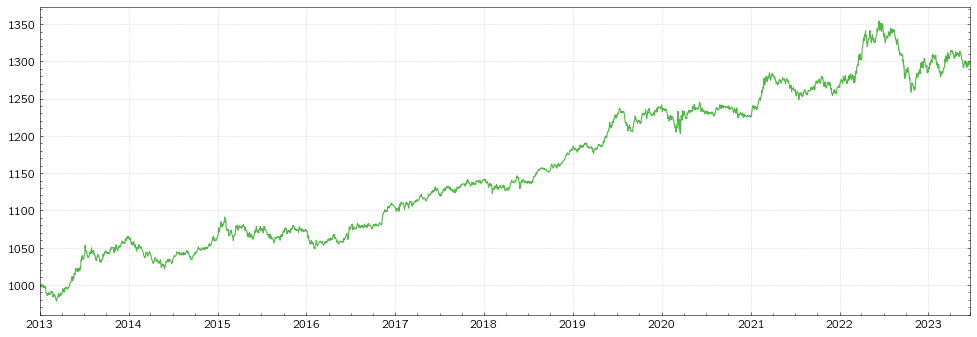

In [56]:
optimized_strategy_inverse_vol.history().plot()

___

## Performance and Analytics

,CPI SIGNAL STRATEGY,USD 14C8124F RSS STRATEGY,USD 297B94B6 BS STRATEGY,INVERSE VOLATILITY BASKET STRATEGY
Annualised Excess Return,2.36%,1.10%,1.74%,2.53%
Annualised Standard Deviation,3.17%,1.23%,1.71%,3.41%
Annualised Sharpe Ratio (vs Cash),0.728,0.863,0.983,0.724
Annualised Sortino Ratio (vs Cash),1.265,1.451,1.710,1.248
Max Drawdown,-4.72%,-2.53%,-3.19%,-7.04%
Kurtosis,2.376,2.710,3.025,3.212
Skewness,0.179,-0.046,0.188,0.197
Mean Positive Return,0.14%,0.06%,0.08%,0.16%
Mean Negative Return,-0.15%,-0.06%,-0.08%,-0.15%
Proportion Positive Returns,54.57%,53.73%,53.26%,52.31%


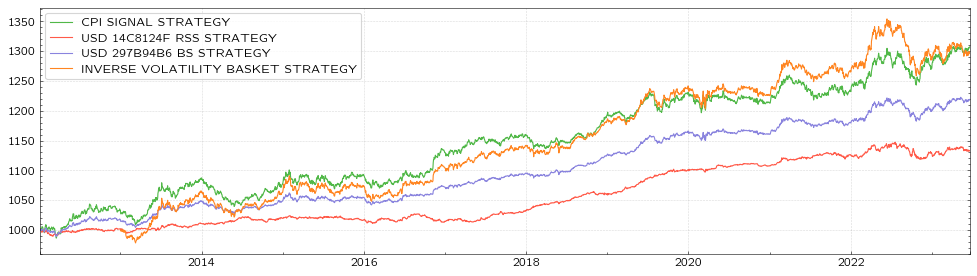

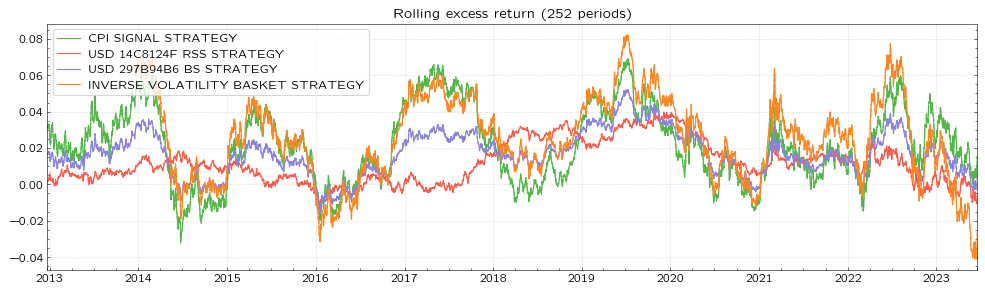

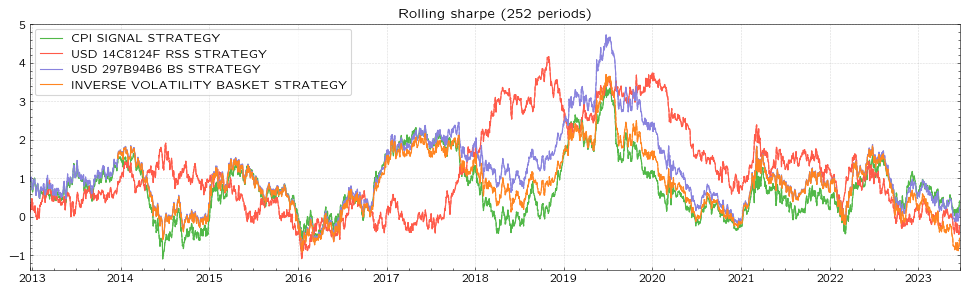

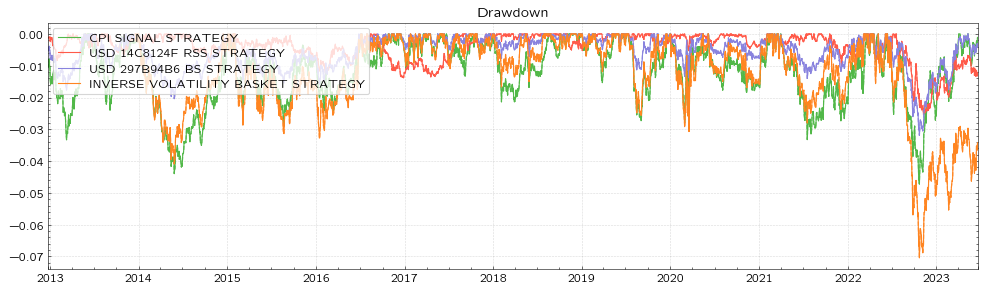

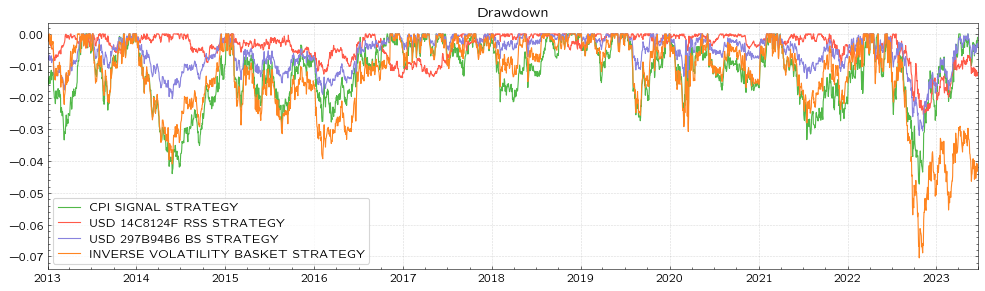

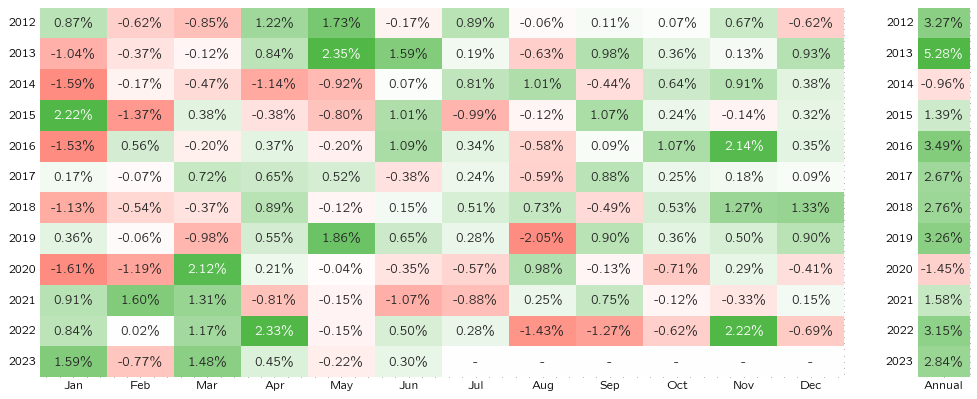

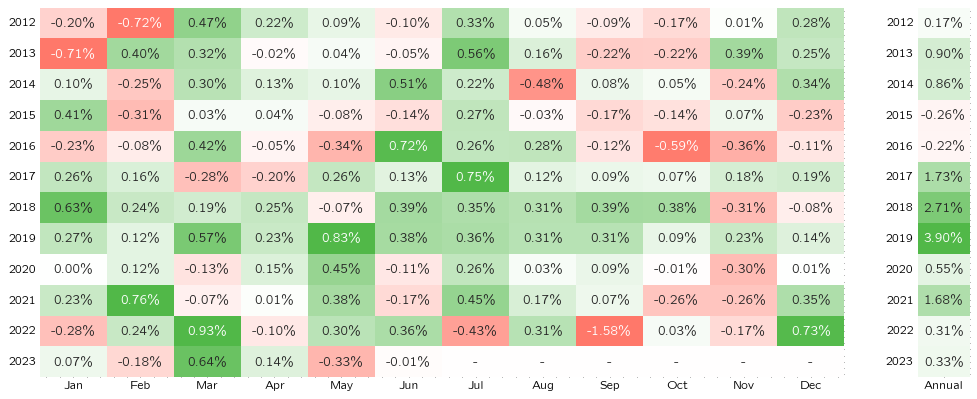

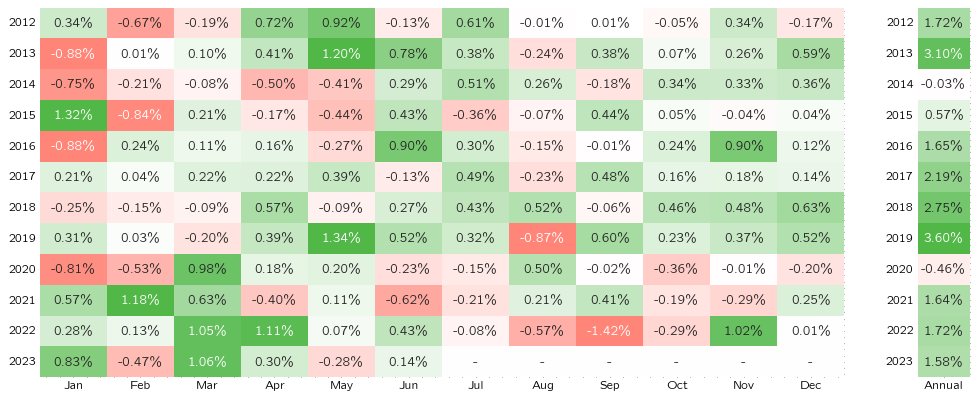

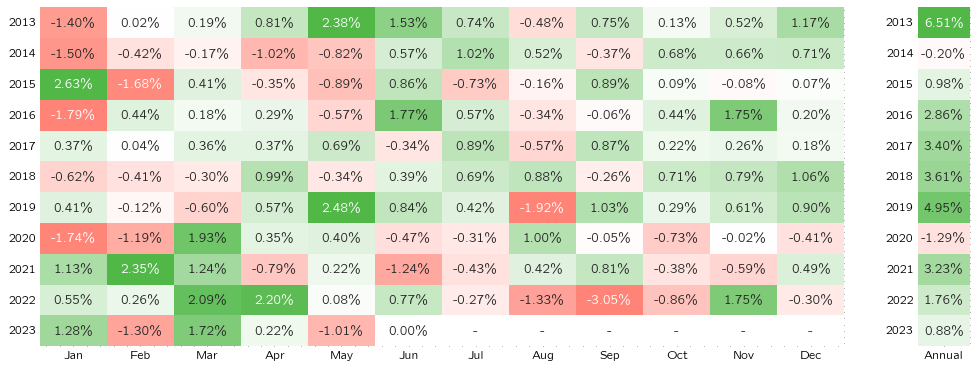

In [57]:
sig.PerformanceReport([cpi_strategy, pv01_strategy, simple_basket, optimized_strategy_inverse_vol]).report()

In [58]:
!jupyter nbconvert --to html swaps_demo.ipynb

[NbConvertApp] Converting notebook swaps_demo.ipynb to html
[NbConvertApp] Writing 1260615 bytes to swaps_demo.html
